<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ResNet-50] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2036 acc 0.505 | val loss 0.8453 acc 0.576 *


[ResNet-50] Epoch   2/100 | LR: 1.00e-04 | train loss 0.7606 acc 0.675 | val loss 0.7336 acc 0.726 *


[ResNet-50] Epoch   3/100 | LR: 1.00e-04 | train loss 0.5501 acc 0.768 | val loss 0.9097 acc 0.778


[ResNet-50] Epoch   4/100 | LR: 1.00e-04 | train loss 0.4679 acc 0.802 | val loss 0.4468 acc 0.807 *


...

[ResNet-50] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0520 acc 0.977 | val loss 0.4896 acc 0.873


[ResNet-50] Epoch  20/100 | LR: 1.00e-05 | train loss 0.0438 acc 0.983 | val loss 0.4363 acc 0.882


[ResNet-50] Epoch  21/100 | LR: 1.00e-05 | train loss 0.0398 acc 0.982 | val loss 0.4537 acc 0.880


[ResNet-50] Epoch  22/100 | LR: 1.00e-05 | train loss 0.0424 acc 0.982 | val loss 0.4155 acc 0.880


[ResNet-50] Epoch  23/100 | LR: 1.00e-05 | train loss 0.0417 acc 0.982 | val loss 0.4062 acc 0.884

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 23.

[ResNet-50] Restored best checkpoint (val loss = 0.3634)


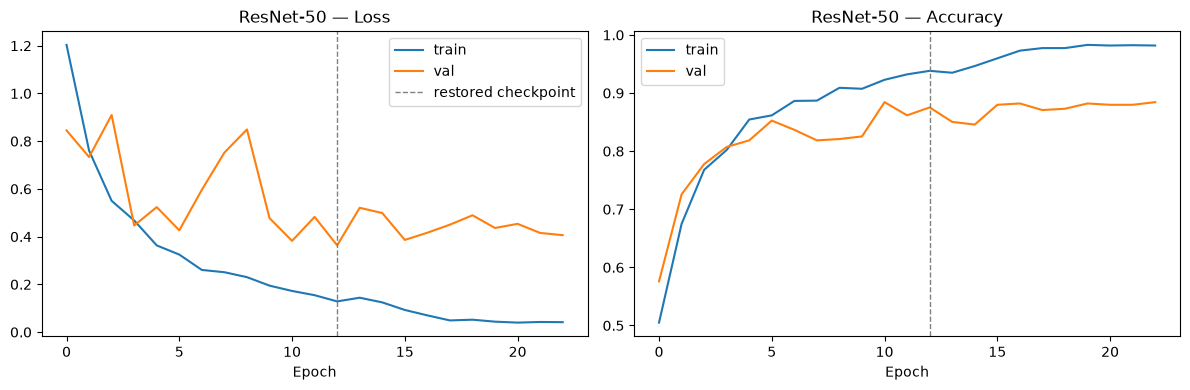

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.770


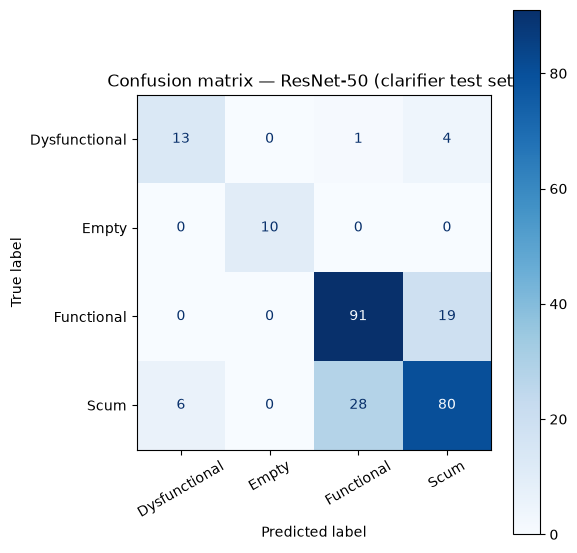

               precision    recall  f1-score   support

Dysfunctional      0.684     0.722     0.703        18
        Empty      1.000     1.000     1.000        10
   Functional      0.758     0.827     0.791       110
         Scum      0.777     0.702     0.737       114

     accuracy                          0.770       252
    macro avg      0.805     0.813     0.808       252
 weighted avg      0.771     0.770     0.769       252



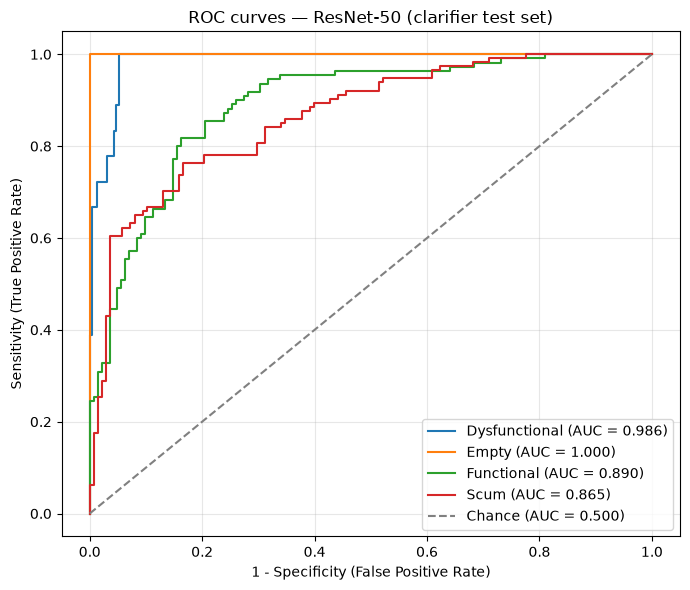

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.986
  Empty          : 1.000
  Functional     : 0.890
  Scum           : 0.865

Mean AUC (over 4/4 classes with test examples): 0.935


(np.float64(0.7698412698412699),
 {'Dysfunctional': 0.9857549857549857,
  'Empty': 1.0,
  'Functional': 0.8901408450704226,
  'Scum': 0.8652428171878973})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_clarifier_resnet50_Fisantekraal.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
